1. 无激活函数单隐藏层神经网络等价于单层网络证明网络结构：
隐藏层：h=W1​x+b1​
输出层：o=W2​h+b2​
推导步骤：将隐藏层代入输出层：o​=W2​(W1​x+b1​)+b2​=W2​W1​x+W2​b1​+b2​​令：
W=W2​W1​,b=W2​b1​+b2​则：
o=Wx+b
结论：无激活函数的多层网络等价于单层线性网络，无法学习非线性模式。

2. Sigmoid 与 tanh 函数及其导数(1) 
Sigmoid定义：σ(x)=1+e−x1
​导数推导：
σ′(x)​=dxd​(1+e−x1​)=(1+e−x)2e−x​=σ(x)(1−σ(x))
​(2) Tanh定义：tanh(x)=ex+e−xex−e−x
​导数推导：
tanh′(x)​=(ex+e−x)2(ex+e−x)2−(ex−e−x)2​=(ex+e−x)24​=1−tanh2(x)​

100%|██████████| 26421880/26421880 [00:04<00:00, 5341907.51it/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 125861.53it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:02<00:00, 1596683.03it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<00:00, 5158212.37it/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Epoch [1/10] | 平均训练损失: 0.5320
Epoch [2/10] | 平均训练损失: 0.3950
Epoch [3/10] | 平均训练损失: 0.3554
Epoch [4/10] | 平均训练损失: 0.3323
Epoch [5/10] | 平均训练损失: 0.3135
Epoch [6/10] | 平均训练损失: 0.2957
Epoch [7/10] | 平均训练损失: 0.2866
Epoch [8/10] | 平均训练损失: 0.2728
Epoch [9/10] | 平均训练损失: 0.2654
Epoch [10/10] | 平均训练损失: 0.2553

✅ 测试集最终准确率: 0.8708


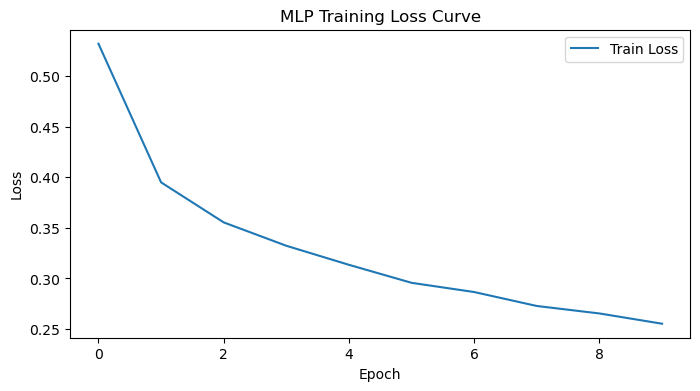

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ===================== 1. 加载Fashion-MNIST数据集 =====================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# 训练集
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# 测试集
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 图片展平维度：28*28=784，分类数10
input_dim = 784
hidden_dim = 128
output_dim = 10

# ===================== 2. 手动正态分布初始化模型参数 =====================
# 隐藏层 W1, b1
W1 = torch.randn(input_dim, hidden_dim) * 0.01
b1 = torch.zeros(1, hidden_dim)
# 输出层 W2, b2
W2 = torch.randn(hidden_dim, output_dim) * 0.01
b2 = torch.zeros(1, output_dim)

# 开启梯度追踪
W1.requires_grad = True
b1.requires_grad = True
W2.requires_grad = True
b2.requires_grad = True

# 超参数
lr = 0.1
epochs = 10

# ===================== 3. 手动实现ReLU激活函数 =====================
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

# ===================== 4. 手动实现带Softmax的交叉熵损失 =====================
def softmax_cross_entropy_loss(y_pred, y_true):
    # 数值稳定版softmax
    x_max = torch.max(y_pred, dim=1, keepdim=True)[0]
    exp_x = torch.exp(y_pred - x_max)
    softmax_out = exp_x / torch.sum(exp_x, dim=1, keepdim=True)
    
    # 交叉熵损失
    one_hot = torch.nn.functional.one_hot(y_true, num_classes=output_dim).float()
    loss = -torch.sum(one_hot * torch.log(softmax_out + 1e-8), dim=1)
    return torch.mean(loss)

# ===================== 5. 小批量SGD训练循环（手动更新参数） =====================
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        # 图像展平：(B,1,28,28) -> (B,784)
        batch_x = batch_x.reshape(-1, input_dim)
        
        # ---------- 前向传播 仅使用torch.matmul ----------
        z1 = torch.matmul(batch_x, W1) + b1  # 隐藏层线性变换
        a1 = relu(z1)                        # ReLU激活
        z2 = torch.matmul(a1, W2) + b2       # 输出层线性变换
        
        # 计算损失
        loss = softmax_cross_entropy_loss(z2, batch_y)
        
        # ---------- 反向传播自动求梯度 ----------
        loss.backward()
        
        # ---------- 手动SGD参数更新 ----------
        with torch.no_grad():
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
        
        # 清空梯度
        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] | 平均训练损失: {avg_loss:.4f}")

# ===================== 6. 测试集准确率计算 =====================
correct = 0
total = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.reshape(-1, input_dim)
        z1 = torch.matmul(batch_x, W1) + b1
        a1 = relu(z1)
        z2 = torch.matmul(a1, W2) + b2
        
        pred = torch.argmax(z2, dim=1)
        total += batch_y.size(0)
        correct += (pred == batch_y).sum().item()

acc = correct / total
print(f"\n✅ 测试集最终准确率: {acc:.4f}")

# ===================== 7. 绘制训练损失曲线 =====================
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.legend()
plt.show()